In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

from utils.dataset import Dataset
from utils.evaluation import evaluate_model

In [8]:
# Path
eval_dir = Path("./evaluation")
data_root = Path("./data/processed")
path = data_root / "df_all.csv"

# Read data and set to datetime
df = pd.read_csv(filepath_or_buffer=path, sep=",")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df = df.set_index("date")

In [10]:
# Instantiate class and create datasets
dataset = Dataset(data=df)

train_dataset, val_dataset, test_dataset = dataset.create_datasets()

Train size: 5352
Val size: 1529
Test size: 765


In [11]:
# Define model
model = XGBRegressor(
    n_estimators=10000,
    max_depth=3,
    learning_rate=0.01,
    # subsample=0.8,
    # colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=20
)

In [12]:
# Fit model
model.fit(
    train_dataset[0], 
    train_dataset[1],
    eval_set=[(val_dataset[0], val_dataset[1])],
    )

[0]	validation_0-rmse:0.82580
[1]	validation_0-rmse:0.81974
[2]	validation_0-rmse:0.81378
[3]	validation_0-rmse:0.80790
[4]	validation_0-rmse:0.80206
[5]	validation_0-rmse:0.79633
[6]	validation_0-rmse:0.79053
[7]	validation_0-rmse:0.78494
[8]	validation_0-rmse:0.77943
[9]	validation_0-rmse:0.77391
[10]	validation_0-rmse:0.76848
[11]	validation_0-rmse:0.76309
[12]	validation_0-rmse:0.75780
[13]	validation_0-rmse:0.75258
[14]	validation_0-rmse:0.74734
[15]	validation_0-rmse:0.74226
[16]	validation_0-rmse:0.73726
[17]	validation_0-rmse:0.73223
[18]	validation_0-rmse:0.72712
[19]	validation_0-rmse:0.72220
[20]	validation_0-rmse:0.71733
[21]	validation_0-rmse:0.71260
[22]	validation_0-rmse:0.70786
[23]	validation_0-rmse:0.70315
[24]	validation_0-rmse:0.69858
[25]	validation_0-rmse:0.69401
[26]	validation_0-rmse:0.68934
[27]	validation_0-rmse:0.68485
[28]	validation_0-rmse:0.68048
[29]	validation_0-rmse:0.67611
[30]	validation_0-rmse:0.67185
[31]	validation_0-rmse:0.66756
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


RMSE: 0.275


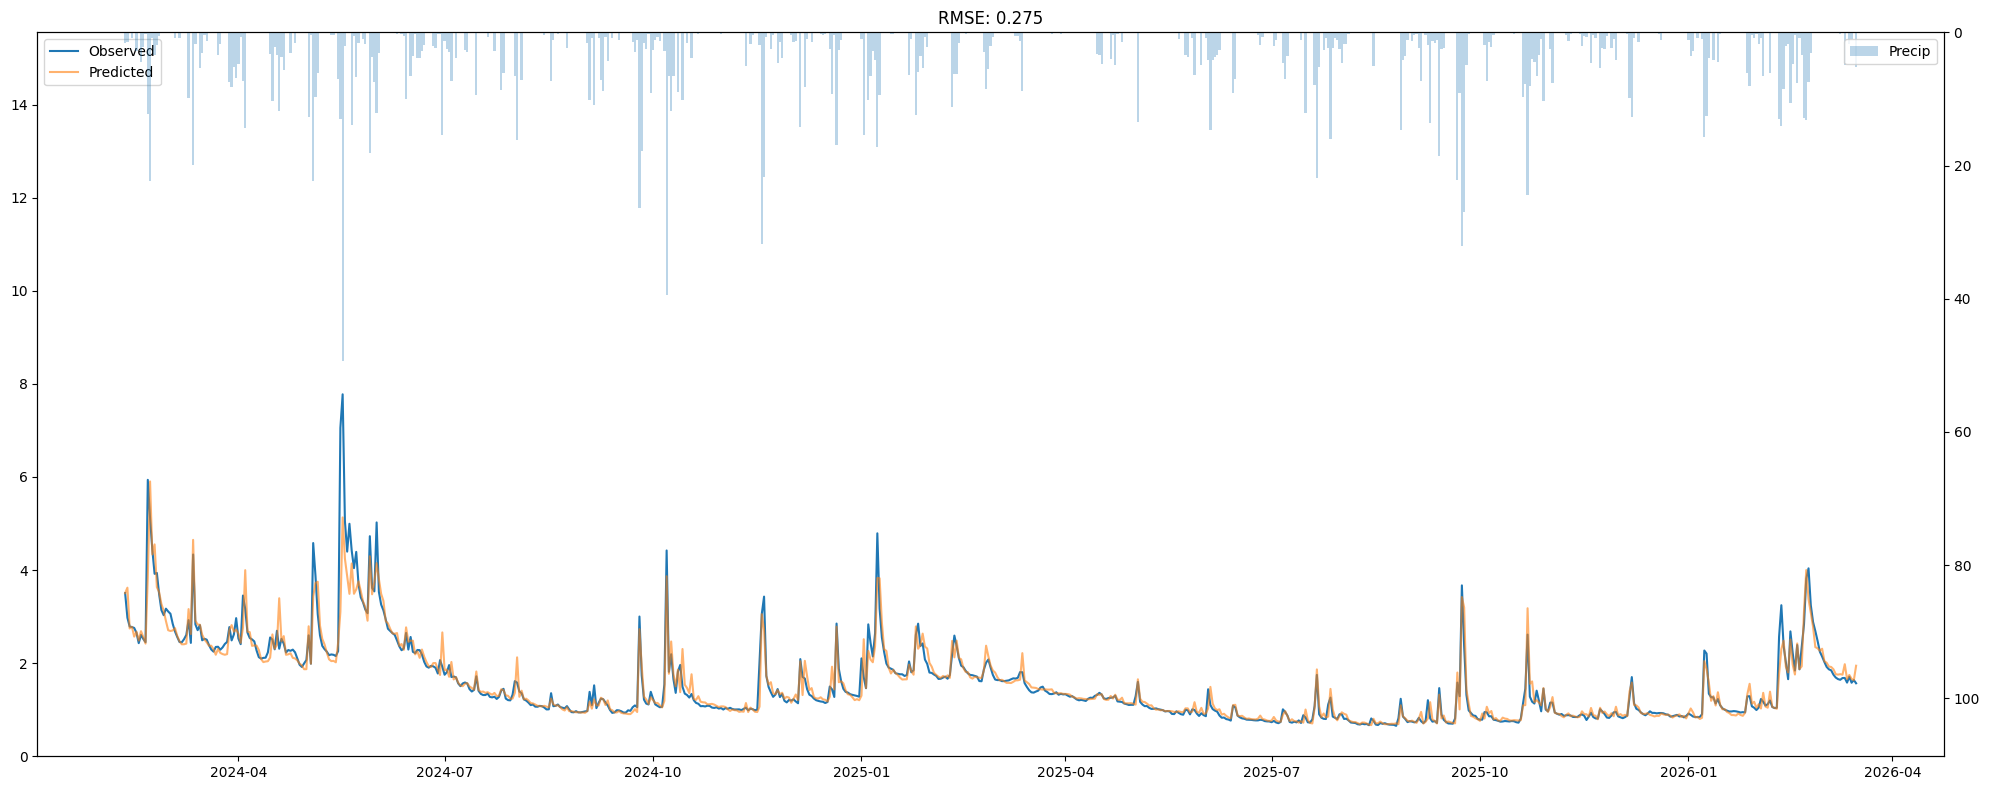

In [13]:
# Predict & evaluate
y_pred = model.predict(test_dataset[0])

evaluate_model(
    model=model,
    dataset=test_dataset, 
    pred=y_pred,
    save_dir=eval_dir,
    )